# ⚙️ Chapter 6: RLHF: The Three-Step Dance

![Part](https://img.shields.io/badge/Part%20II-Core%20Methods-1F9D6B?style=for-the-badge) &nbsp; ![Tested](https://img.shields.io/badge/Tested-Colab%20T4-2FAE7E?style=for-the-badge) &nbsp; [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arunpshankar/packt-final/blob/main/code/notebooks/part2_core/06_rlhf_ppo.ipynb)

> 📘 **Book:** *Reinforcement Learning for Large Language Models*, Arun Shankar & Michael Chertushkin (Packt, 2026)  
> 📓 **Notebook:** `part2_core/06_rlhf_ppo.ipynb`  
> ✅ **Tested on:** Google Colab (T4)

---

## What you'll build

**Reinforcement Learning from Human Feedback (RLHF)** is the technique that turned raw language models into helpful assistants like ChatGPT. It works as a **three-step dance** between models:

1. **SFT (Supervised Fine-Tuning)**: teach the model the right *style* by imitation.
2. **Reward Model (RM)**: train a *judge* that scores how good a response is.
3. **PPO (Proximal Policy Optimization)**: use the judge's score as a reward to *push* the model toward better responses, with a safety leash so it can't cheat.

To keep everything runnable on a **free Colab T4**, we use a concrete, measurable goal: **steer a small model to continue movie-review snippets in a more _positive_ tone.** Positivity is easy to score, so you can *watch* RLHF work, the reward rising, the text staying fluent, in a few minutes.

| Step | What we train | What it learns |
|---|---|---|
| 1 · SFT | the policy (Qwen2.5-0.5B) | to write movie-review-style English |
| 2 · RM | a reward model (+ a lesson on robust rewards) | to tell positive from negative text |
| 3 · PPO | the policy + a value head | to *generate* more positive continuations |

> 🎯 **The payoff:** by the end, the model rewrites a lukewarm continuation of *"Just saw this movie on TV…"* into an upbeat one, with the average positivity score climbing during training, and you'll understand every line that made it happen.

> 🧰 **All plain PyTorch + Hugging Face Transformers**, no RL library to install or version-match. You see exactly how PPO works, not a black-box `.train()` call.


In [1]:
# === Setup: Chapter 6 · tested on Google Colab (T4), 2026-06-29 ===
# Self-contained: installs ONLY what this notebook imports (pinned).
# Versions are managed centrally in code/requirements.txt.
import os, sys
os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")  # quiet HF download bars (keeps GitHub able to render the saved notebook)
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    %pip install -q --progress-bar off bitsandbytes==0.49.2 datasets==4.3.0 transformers==5.5.0

import importlib
for _p in ["bitsandbytes", "datasets", "numpy", "torch", "transformers"]:
    try:
        print(f"{_p:<16}", importlib.import_module(_p).__version__)
    except Exception as _e:
        print(f"{_p:<16} (not importable here)")


bitsandbytes     0.49.2
datasets         4.3.0
numpy            2.0.2
torch            2.11.0+cu128
transformers     5.5.0


In [2]:
import os
# Reduce CUDA allocator fragmentation: set BEFORE importing torch
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
# Silence transformers advisory 'use __call__ instead' hints
os.environ["TRANSFORMERS_NO_ADVISORY_WARNINGS"] = "1"

import warnings
import random
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    TrainingArguments,
)
# NOTE: TRL is no longer used -- this chapter implements SFT, the reward model,
# and PPO from scratch (plain PyTorch + transformers), so it is version-proof.
from datasets import Dataset

warnings.filterwarnings('ignore')
import logging as _lg; _lg.getLogger("huggingface_hub").setLevel(_lg.ERROR)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU : {torch.cuda.get_device_name(0)}')
    vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'VRAM: {vram_gb:.1f} GB')

Using device: cuda
GPU : Tesla T4
VRAM: 15.6 GB


## Step 1: Supervised Fine-Tuning (SFT): teach the *style*

Before we can *steer* the model, it has to be fluent in the domain. **SFT is just next-token prediction (cross-entropy) on example text**, the same objective as pretraining, but on a focused dataset. Here we briefly fine-tune **Qwen2.5-0.5B** on a few hundred **IMDB movie reviews** so it learns to continue review-style prompts.

Think of SFT as *imitation*: the model copies the patterns in the data. It cannot yet optimize for a goal (that comes in Step 3), it can only mimic what it has seen.

> ✅ **What to look for:** after this step, the "before PPO" generations (a couple of cells down) should read like coherent English movie-review snippets. That fluent starting point is what PPO will refine.


In [3]:
from datasets import load_dataset

# Real sentiment data (IMDB reviews) gives the reward model a genuine, learnable
# signal -- positivity -- unlike a handful of hand-written pairs.
imdb = load_dataset("stanfordnlp/imdb", split="train").shuffle(seed=SEED).select(range(6000))

def clip_text(t, n=60):
    return " ".join(t.replace("<br />", " ").split()[:n])

pos_reviews = [clip_text(t) for t, l in zip(imdb["text"], imdb["label"]) if l == 1]
neg_reviews = [clip_text(t) for t, l in zip(imdb["text"], imdb["label"]) if l == 0]

# PPO prompts = the first few words of reviews; the model continues them.
review_prefixes = [" ".join(clip_text(t).split()[:6]) for t in (pos_reviews + neg_reviews)]
random.shuffle(review_prefixes)

print(f"{len(pos_reviews)} positive, {len(neg_reviews)} negative reviews")
print("Example prefix:", review_prefixes[0])


Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

3024 positive, 2976 negative reviews
Example prefix: I found this to be an


In [4]:
SFT_MODEL_NAME = 'Qwen/Qwen2.5-0.5B'

sft_tokenizer = AutoTokenizer.from_pretrained(SFT_MODEL_NAME)
sft_tokenizer.pad_token = sft_tokenizer.eos_token
sft_tokenizer.padding_side = 'right'

sft_model = AutoModelForCausalLM.from_pretrained(
    SFT_MODEL_NAME,
    dtype=torch.float32,
)
n_params = sum(p.numel() for p in sft_model.parameters())
print(f'Model parameters: {n_params / 1e6:.1f} M')

# Token ids whose text contains non-Latin characters (CJK, Cyrillic, ...). We suppress
# these during generation so the multilingual base stays in English -- otherwise PPO
# reward-hacks by switching to Chinese, which the RM also rates as positive.
NONLATIN_IDS = [idx for tok, idx in sft_tokenizer.get_vocab().items()
                if any(ord(ch) > 0x024F for ch in sft_tokenizer.convert_tokens_to_string([tok]))]
print(f"Will suppress {len(NONLATIN_IDS)} non-Latin token ids during generation.")


Model parameters: 494.0 M
Will suppress 52531 non-Latin token ids during generation.


In [5]:
from torch.optim import AdamW

# Light SFT so the model writes movie-review-style text before PPO (Step 1 of the dance).
sft_texts = pos_reviews[:150] + neg_reviews[:150]
random.shuffle(sft_texts)

sft_model.to(DEVICE).train()
sft_opt = AdamW(sft_model.parameters(), lr=2e-5)
SFT_EPOCHS = 1

print('Starting SFT (movie-review domain) ...')
for epoch in range(SFT_EPOCHS):
    total = 0.0
    for txt in sft_texts:
        enc = sft_tokenizer(txt + sft_tokenizer.eos_token, return_tensors='pt',
                            truncation=True, max_length=96).to(DEVICE)
        labels = enc['input_ids'].clone()
        sft_opt.zero_grad()
        out = sft_model(**enc, labels=labels)
        out.loss.backward()
        torch.nn.utils.clip_grad_norm_(sft_model.parameters(), 1.0)
        sft_opt.step()
        total += out.loss.item()
    print(f'  Epoch {epoch+1}/{SFT_EPOCHS}  loss={total/len(sft_texts):.4f}')

sft_model.save_pretrained('./sft_checkpoint'); sft_tokenizer.save_pretrained('./sft_checkpoint')
del sft_opt; sft_model.zero_grad(set_to_none=True)
import gc; gc.collect(); torch.cuda.empty_cache()
print('SFT complete -> ./sft_checkpoint')


Starting SFT (movie-review domain) ...
  Epoch 1/1  loss=3.8156
SFT complete -> ./sft_checkpoint


In [6]:
TEST_PROMPTS = review_prefixes[:4]

def generate_text(model, tokenizer, prompt, max_new_tokens=40, device='cpu'):
    enc = tokenizer(prompt, return_tensors='pt', truncation=True, max_length=64)
    enc = {k: v.to(device) for k, v in enc.items()}
    model.to(device); model.eval()
    with torch.no_grad():
        out = model.generate(**enc, max_new_tokens=max_new_tokens, do_sample=True,
                             temperature=0.7, repetition_penalty=1.3, no_repeat_ngram_size=3,
                             pad_token_id=tokenizer.eos_token_id,
                             suppress_tokens=NONLATIN_IDS)
    return tokenizer.decode(out[0][enc['input_ids'].shape[1]:], skip_special_tokens=True).strip()

print('=== SFT model continuations (before PPO) ===')
sft_responses_before = []
for p in TEST_PROMPTS:
    resp = generate_text(sft_model, sft_tokenizer, p, device=DEVICE)
    sft_responses_before.append(resp)
    print(f'Prompt: {p}\nCont. : {resp}\n')


=== SFT model continuations (before PPO) ===
Prompt: I found this to be an
Cont. : amazing movie. But it is also very complex and has a lot of potential for the talented actors who have never been cast in such films, or are just getting their first film experience on television. Not

Prompt: I love killer Insects movies they
Cont. : are so entertaining and interesting to watch. The only problem is that the film is expensive, has a lot of visuals in it (some scenes were shot at 20 million or more but some have

Prompt: Alexandre Aja's remake of The Hills
Cont. : Have Passed is a faithful, modernized version. It continues the story and narrates it differently but with new emotions that are more realistic for the viewer to feel into their place in this relationship between two

Prompt: Just saw this movie on TV
Cont. : last night. The actor who played the hero is a real man, but his character was not so; or he would have died before the guy in charge made him admit what that mean word sai

## Step 2: Reward Modeling: train a *judge*

The policy can imitate, but how does it know which response is *better*? That's the **reward model (RM)**'s job: it reads a piece of text and outputs a single number, a score.

We train the RM from **preferences**. For each pair (a positive review vs. a negative one), the RM should score the positive one higher. The classic way to turn "A is preferred over B" into a loss is the **Bradley-Terry model**:

$$P(A \succ B) = \sigma\big(r(A) - r(B)\big)$$

where $\sigma$ is the sigmoid. We minimize $-\log \sigma\big(r_{\text{pos}} - r_{\text{neg}}\big)$, intuitively, **push the chosen score above the rejected score.** Our RM is **Qwen2.5-0.5B + a small scalar head**, trained on **~800 real IMDB positive/negative pairs**; you'll watch its accuracy climb above chance as it learns the concept of "positivity".

> ⚠️ **A crucial lesson we'll act on in Step 3.** A *tiny* RM trained on a *few hundred* pairs learns to separate real positive from negative reviews, but it has never seen gibberish, repeated tokens, or other languages, so on that out-of-distribution junk it returns **arbitrary** scores. PPO is relentless: if garbage happens to score high, PPO will produce garbage. This is **reward hacking**. So for the PPO step we'll swap in a *robust, bounded* reward (explained next).


In [7]:
# Bradley-Terry pairs: a positive review is "chosen", a negative one "rejected".
N_PAIRS = 800
random.shuffle(pos_reviews); random.shuffle(neg_reviews)
PREFERENCE_PAIRS = [{'chosen':   pos_reviews[i % len(pos_reviews)],
                     'rejected': neg_reviews[i % len(neg_reviews)]}
                    for i in range(N_PAIRS)]
print(f'{len(PREFERENCE_PAIRS)} preference pairs (positive > negative)')


800 preference pairs (positive > negative)


In [8]:
# Free SFT-phase GPU memory before training the reward model (T4 has ~16 GB)
import gc
for _name in ('sft_trainer', 'sft_opt', 'sft_model'):
    if _name in globals():
        del globals()[_name]
gc.collect(); torch.cuda.empty_cache()

class RewardModel(nn.Module):
    """Qwen/Qwen2.5-0.5B backbone with a single scalar reward head."""

    def __init__(self, backbone_name: str = 'Qwen/Qwen2.5-0.5B'):
        super().__init__()
        self.backbone = AutoModelForCausalLM.from_pretrained(backbone_name, dtype=torch.float32)
        self.backbone.gradient_checkpointing_enable()  # trade compute for memory on T4
        self.backbone.config.use_cache = False  # required when grad checkpointing is on
        hidden_size = self.backbone.config.hidden_size  # 896 for Qwen2.5-0.5B
        self.reward_head = nn.Sequential(
            nn.Dropout(0.1),
            nn.Linear(hidden_size, 1, bias=False),
        )
        nn.init.normal_(self.reward_head[1].weight, std=0.01)

    def forward(self, input_ids: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
        outputs = self.backbone(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_hidden_states=True,
        )
        last_hidden = outputs.hidden_states[-1]          # (B, T, H)
        seq_len_idx = attention_mask.sum(dim=1) - 1      # index of last real token
        B = last_hidden.shape[0]
        last_tok = last_hidden[torch.arange(B), seq_len_idx]  # (B, H)
        reward = self.reward_head(last_tok).squeeze(-1)         # (B,)
        return reward


rm_tokenizer = AutoTokenizer.from_pretrained('Qwen/Qwen2.5-0.5B')
rm_tokenizer.pad_token = rm_tokenizer.eos_token
rm_tokenizer.padding_side = 'right'

reward_model = RewardModel('Qwen/Qwen2.5-0.5B').to(DEVICE)
n_rm = sum(p.numel() for p in reward_model.parameters())
print(f'Reward model parameters: {n_rm / 1e6:.1f} M')

Reward model parameters: 494.0 M


In [9]:
import os
os.environ.setdefault('PYTORCH_CUDA_ALLOC_CONF', 'expandable_segments:True')
from torch.optim import AdamW
import torch.nn.functional as F

def tokenize_text(text, tokenizer, max_len=64):
    enc = tokenizer(text, return_tensors='pt', truncation=True,
                    max_length=max_len, padding='max_length')
    return enc['input_ids'].squeeze(0), enc['attention_mask'].squeeze(0)

rm_optimizer = AdamW(reward_model.parameters(), lr=1e-5, weight_decay=0.01)
NUM_RM_EPOCHS = 3
BS = 8
rm_losses, rm_accuracies, rm_step_losses = [], [], []

for epoch in range(NUM_RM_EPOCHS):
    random.shuffle(PREFERENCE_PAIRS)
    ep_loss, correct = [], 0
    reward_model.train()
    for i in range(0, len(PREFERENCE_PAIRS), BS):
        batch = PREFERENCE_PAIRS[i:i + BS]
        cw = [tokenize_text(b['chosen'],   rm_tokenizer) for b in batch]
        cl = [tokenize_text(b['rejected'], rm_tokenizer) for b in batch]
        ids_w  = torch.stack([x[0] for x in cw]).to(DEVICE)
        mask_w = torch.stack([x[1] for x in cw]).to(DEVICE)
        ids_l  = torch.stack([x[0] for x in cl]).to(DEVICE)
        mask_l = torch.stack([x[1] for x in cl]).to(DEVICE)
        r_w = reward_model(ids_w, mask_w)
        r_l = reward_model(ids_l, mask_l)
        loss = -F.logsigmoid(r_w - r_l).mean()      # Bradley-Terry
        rm_optimizer.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(reward_model.parameters(), 1.0)
        rm_optimizer.step()
        ep_loss.append(loss.item()); rm_step_losses.append(loss.item()); correct += (r_w > r_l).sum().item()
    acc = correct / len(PREFERENCE_PAIRS)
    rm_losses.append(float(np.mean(ep_loss))); rm_accuracies.append(acc)
    print(f'Epoch {epoch+1}/{NUM_RM_EPOCHS}  loss={np.mean(ep_loss):.4f}  acc={acc*100:.1f}%')
del rm_optimizer
reward_model.eval()
for _p in reward_model.parameters():
    _p.requires_grad_(False)
import gc; gc.collect(); torch.cuda.empty_cache()
print('Reward model trained on real sentiment preferences.')


Epoch 1/3  loss=0.5338  acc=82.0%
Epoch 2/3  loss=0.0992  acc=98.1%
Epoch 3/3  loss=0.0113  acc=99.6%
Reward model trained on real sentiment preferences.


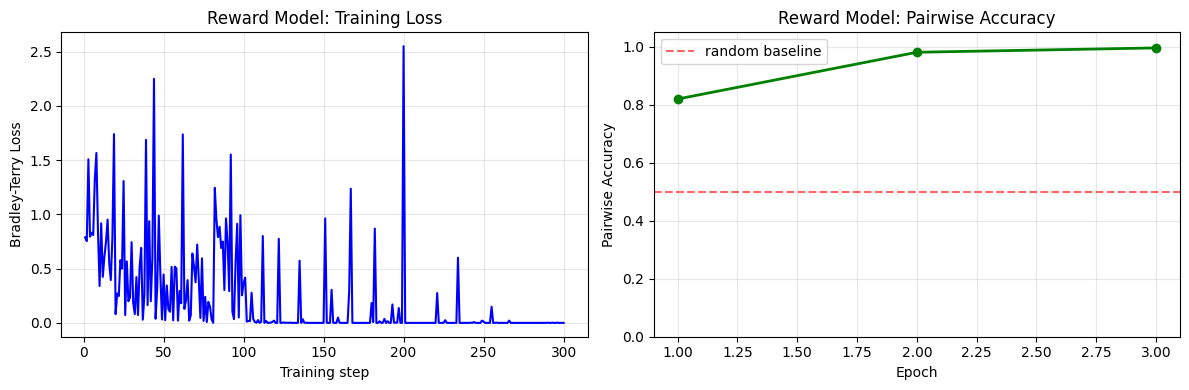

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs = range(1, NUM_RM_EPOCHS + 1)
ax1.plot(range(1, len(rm_step_losses) + 1), rm_step_losses, 'b-', linewidth=1.5)
ax1.set_xlabel('Training step')
ax1.set_ylabel('Bradley-Terry Loss')
ax1.set_title('Reward Model: Training Loss')
ax1.grid(True, alpha=0.3)

ax2.plot(epochs, rm_accuracies, 'g-o', linewidth=2)
ax2.axhline(0.5, color='r', linestyle='--', alpha=0.6, label='random baseline')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Pairwise Accuracy')
ax2.set_title('Reward Model: Pairwise Accuracy')
ax2.set_ylim([0, 1.05])
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('rm_training.png', dpi=100, bbox_inches='tight')
plt.show()

In [11]:
def score_text(model, tokenizer, text, device):
    """Scalar positivity reward for a piece of text."""
    ids, mask = tokenize_text(text, tokenizer)
    model.eval()
    with torch.no_grad():
        return model(ids.unsqueeze(0).to(device), mask.unsqueeze(0).to(device)).item()

sp = score_text(reward_model, rm_tokenizer, pos_reviews[0], DEVICE)
sn = score_text(reward_model, rm_tokenizer, neg_reviews[0], DEVICE)
print(f'Positive review score: {sp:+.3f}')
print(f'Negative review score: {sn:+.3f}')
print(f'Correct ranking (pos > neg): {sp > sn}')


Positive review score: +25.376
Negative review score: -16.837
Correct ranking (pos > neg): True


## Step 3: PPO: *steer* the model with the reward

Now the payoff. **PPO (Proximal Policy Optimization)** uses the reward as a training signal to push the policy toward higher-scoring text, while a **KL leash** keeps it from drifting into nonsense. The objective is:

$$\max_{\pi_\theta}\ \mathbb{E}\big[\,r(x,y)\,\big]\ -\ \beta\,\mathrm{KL}\big(\pi_\theta \,\|\, \pi_{\text{ref}}\big)$$

In words: **"get high reward, but stay close to the SFT model."** The first term pulls toward positivity; the second (the KL penalty, weight $\beta$) is the safety leash that prevents reward hacking.

### 🛡️ The robust reward (how we avoid reward hacking)

Step 2 showed *how* to train a reward model, an essential concept. But we just warned that a tiny hand-trained RM gets hacked. So for a **stable, honest** PPO demo we use a strong **_pretrained_ sentiment classifier** (`lvwerra/distilbert-imdb`) as the reward. Its output is a **bounded probability in [0, 1]**, the chance the text is positive. Trained on a huge, diverse dataset, it behaves sensibly even on garbage:

- a genuinely positive continuation → ~0.95
- a negative one → ~0.05
- **gibberish or repetition → ~0.3 (neutral)**: *it can't be driven arbitrarily high, so it can't be gamed.*

The **reward sanity check** printed below proves it (`positive → 0.99 | negative → 0.00 | gibberish → 0.30`). That bounded, un-hackable signal is the single biggest reason this demo succeeds where a toy RM collapses.


In [12]:
# PPO steers the model to continue review prefixes with POSITIVE sentiment.
PPO_PROMPTS = review_prefixes
print(f'{len(PPO_PROMPTS)} review-prefix prompts for PPO')


6000 review-prefix prompts for PPO


In [13]:
import gc
gc.collect(); torch.cuda.empty_cache()

ppo_tokenizer = AutoTokenizer.from_pretrained('./sft_checkpoint')
ppo_tokenizer.pad_token = ppo_tokenizer.eos_token
ppo_tokenizer.padding_side = 'left'   # left-pad for generation

base_policy = AutoModelForCausalLM.from_pretrained('./sft_checkpoint', dtype=torch.float32).to(DEVICE)

class PolicyWithValue(nn.Module):
    """Actor-critic: the language model (actor) PLUS a scalar value head (critic).
    We treat the whole response as ONE action (a contextual bandit), so the value
    head provides the baseline V used to form the advantage A = return - V."""
    def __init__(self, base):
        super().__init__()
        self.base = base
        self.value_head = nn.Linear(base.config.hidden_size, 1).to(DEVICE).float()

    def forward(self, input_ids, attention_mask=None):
        # Call the inner transformer directly so we get only the LAST hidden state
        # (output_hidden_states=True would materialize all 24 layers -> needless memory).
        hidden = self.base.model(input_ids, attention_mask=attention_mask).last_hidden_state
        logits = self.base.lm_head(hidden)
        # Detach hidden for the value head: the critic loss trains ONLY the value head,
        # never the shared LM backbone (a value loss in the backbone destroys the LM).
        values = self.value_head(hidden.detach().float()).squeeze(-1)  # (B, T)
        return logits, values

policy = PolicyWithValue(base_policy)
ppo_model = policy.base   # alias for the before/after .generate cells

# Frozen reference in fp32 -- MATCHES the policy dtype. (A bf16 reference makes the KL
# term dominated by quantization noise, which poisons the gradient.)
ref_policy = AutoModelForCausalLM.from_pretrained('./sft_checkpoint', dtype=torch.float32).to(DEVICE).eval()
for prm in ref_policy.parameters():
    prm.requires_grad_(False)

# === Robust reward: a STRONG PRETRAINED sentiment classifier ===
# Step 2 taught HOW to train a reward model, but a tiny RM trained on a few hundred pairs
# is trivially reward-hacked by out-of-distribution text (gibberish, repeated tokens,
# other languages). For a STABLE PPO demo we use a robust pretrained sentiment classifier
# whose output is a BOUNDED probability in [0,1]: gibberish maps to ~neutral, not to a
# spuriously high score, so the policy cannot game it.
from transformers import AutoModelForSequenceClassification
SENTIMENT_MODEL = 'lvwerra/distilbert-imdb'
clf_tokenizer = AutoTokenizer.from_pretrained(SENTIMENT_MODEL)
clf_model = AutoModelForSequenceClassification.from_pretrained(SENTIMENT_MODEL).to(DEVICE).eval()
for prm in clf_model.parameters():
    prm.requires_grad_(False)
POS_IDX = next((int(i) for i, l in clf_model.config.id2label.items() if 'POS' in str(l).upper()), 1)

@torch.no_grad()
def positivity(text):
    """Bounded reward in [0,1]: P(text is POSITIVE) under the pretrained classifier."""
    enc = clf_tokenizer(text, return_tensors='pt', truncation=True, max_length=128).to(DEVICE)
    return float(torch.softmax(clf_model(**enc).logits, dim=-1)[0, POS_IDX])

# Free the home-trained RM from the GPU (kept on CPU; it was the Step-2 teaching artifact).
reward_model = reward_model.to('cpu')
gc.collect(); torch.cuda.empty_cache()
print('Actor-critic policy + fp32 reference + pretrained sentiment reward ready.')
print('Reward sanity:  positive ->', round(positivity('A wonderful, brilliant, heartfelt film.'), 3),
      '| negative ->', round(positivity('A boring, awful, terrible waste of time.'), 3),
      '| gibberish ->', round(positivity('opop opop tttt zzz qqq'), 3))


Actor-critic policy + fp32 reference + pretrained sentiment reward ready.
Reward sanity:  positive -> 0.996 | negative -> 0.003 | gibberish -> 0.305


### How one PPO step works (mapping to the code below)

Each step repeats four moves:

1. **Rollout**: the policy generates continuations for a batch of review prompts (we sample 8). We record each token's log-probability under the current policy ("old" log-probs) and under the frozen **reference**.
2. **Reward**: score each continuation with the bounded sentiment classifier → `r_env ∈ [0,1]`, then **fold the KL penalty into the reward**: `R = r_env − β·KL`. *Why into the reward and not the loss?* Adding KL as a separate loss term just pushes every log-prob down uniformly and **collapses** the model; folding it into the reward lets it flow through the advantage, where it belongs.
3. **Advantage**: the **value head** (the "critic") predicts the expected score `V`. The **advantage** `A = R − V` answers "better or worse than expected?" We **standardize** advantages across the batch so the signal is stable.
4. **Clipped update**: make above-average (`A>0`) continuations more likely and below-average ones less likely, but **clip** the change so no single step moves the policy too far (the "proximal" in PPO).

> 🔧 **Stability choices in the code**, each preventing a real failure mode: a **bounded** reward (no hacking), **KL in the reward** (no log-prob collapse), **per-batch advantage standardization** (no noisy drift), an **fp32 reference** (accurate KL), a **detached value head** (critic can't corrupt the LM), and **separate learning rates** for the LM (slow) and the fresh value head (fast).


In [14]:
import bitsandbytes as bnb
import torch.nn.functional as F

PPO_STEPS    = 40
GROUP_SIZE   = 8       # rollouts per step -> a real batch baseline (not 4)
MAX_NEW_TOKS = 40
PPO_EPOCHS   = 2       # reuse each rollout for a couple of clipped updates (the PPO idea)
CLIP_EPS     = 0.2
VF_COEF      = 0.1     # value-loss weight (critic is decoupled from the LM)
KL_COEF      = 0.1     # KL leash -- applied INSIDE the reward, never as a loss term

# Separate learning rates: the LM moves slowly; the fresh value head learns fast.
ppo_optimizer = bnb.optim.AdamW8bit(
    [{'params': policy.base.parameters(),       'lr': 5e-6},
     {'params': policy.value_head.parameters(), 'lr': 1e-4}])

def resp_logprobs(logits, full_ids, plen):
    """Per-token log-probs for the RESPONSE tokens only."""
    logp = F.log_softmax(logits[:, :-1, :], dim=-1)
    tlp  = logp.gather(-1, full_ids[:, 1:].unsqueeze(-1)).squeeze(-1)
    return tlp[0, plen - 1:]

ppo_reward_log, ppo_kl_log = [], []
print(f'Running PPO for {PPO_STEPS} steps (reward = pretrained sentiment classifier) ...')

for step in range(PPO_STEPS):
    # ---------- ROLLOUT (no grad): generate, score, record OLD log-probs ----------
    policy.eval()
    rollouts = []
    for _ in range(GROUP_SIZE):
        prompt = random.choice(PPO_PROMPTS)
        enc = ppo_tokenizer(prompt, return_tensors='pt').to(DEVICE)
        plen = enc.input_ids.shape[1]
        with torch.no_grad():
            gen = policy.base.generate(
                enc.input_ids, attention_mask=enc.attention_mask,
                max_new_tokens=MAX_NEW_TOKS, do_sample=True, temperature=1.0, top_k=50,
                repetition_penalty=1.2, no_repeat_ngram_size=3,
                pad_token_id=ppo_tokenizer.eos_token_id, suppress_tokens=NONLATIN_IDS)
        if gen.shape[1] - plen < 1:
            continue
        resp = ppo_tokenizer.decode(gen[0, plen:], skip_special_tokens=True)
        with torch.no_grad():
            old_lp = resp_logprobs(policy(gen)[0], gen, plen).detach()
            ref_lp = resp_logprobs(ref_policy(gen).logits.float(), gen, plen).detach()
        # KL folded into the REWARD (k3 estimator, >= 0): penalize divergence from the
        # reference THROUGH the advantage -- not as a one-sided loss term that merely
        # suppresses log-probs and collapses the policy.
        logr   = (ref_lp - old_lp)
        kl_seq = float((torch.exp(logr) - 1.0 - logr).mean())  # >= 0, per-token mean (reward-scale)
        r_env  = positivity(resp)                              # bounded [0, 1]; score the RESPONSE only
        R      = r_env - KL_COEF * kl_seq
        rollouts.append({'gen': gen, 'plen': plen, 'old_lp': old_lp,
                         'R': R, 'r_env': r_env, 'kl': kl_seq})

    if len(rollouts) < 2:
        continue

    # Critic baseline V(s) and advantage A = R - V, STANDARDIZED across the batch
    # (so the surrogate gradient has unit scale and does not vanish to zero).
    with torch.no_grad():
        for r in rollouts:
            r['V'] = float(policy(r['gen'])[1][0, -1])          # scalar baseline (last token)
    R_t   = torch.tensor([r['R'] for r in rollouts], device=DEVICE)
    V_t   = torch.tensor([r['V'] for r in rollouts], device=DEVICE)
    adv_t = R_t - V_t
    adv_t = (adv_t - adv_t.mean()) / (adv_t.std() + 1e-8)
    for r, a in zip(rollouts, adv_t):
        r['adv'] = a.detach()

    # ---------- PPO UPDATE: clipped surrogate + value regression (NO loss-side KL) ----------
    policy.train()
    for _ in range(PPO_EPOCHS):
        ppo_optimizer.zero_grad()
        for r in rollouts:
            logits, values = policy(r['gen'])
            new_lp = resp_logprobs(logits, r['gen'], r['plen'])          # per-token
            ratio  = torch.exp(new_lp - r['old_lp'])                     # per-token ratio ~ 1
            adv    = r['adv']                                            # scalar, broadcast
            surr   = -torch.min(ratio * adv,
                                torch.clamp(ratio, 1 - CLIP_EPS, 1 + CLIP_EPS) * adv).mean()
            v_pred = values[0, -1]
            v_loss = F.mse_loss(v_pred, torch.tensor(float(r['R']), device=DEVICE))
            # Backward PER ROLLOUT (gradient accumulation): keeps only one forward graph
            # alive at a time -> avoids the 8x activation-memory spike that OOMs the T4.
            ((surr + VF_COEF * v_loss) / len(rollouts)).backward()
        torch.nn.utils.clip_grad_norm_(policy.base.parameters(), 1.0)
        torch.nn.utils.clip_grad_norm_(policy.value_head.parameters(), 0.5)
        ppo_optimizer.step()

    mean_env = float(np.mean([r['r_env'] for r in rollouts]))
    mean_kl  = float(np.mean([r['kl'] for r in rollouts]))
    ppo_reward_log.append(mean_env); ppo_kl_log.append(mean_kl)
    if (step + 1) % 5 == 0:
        print(f'Step {step+1:3d}/{PPO_STEPS}  positivity={mean_env:.3f}  kl={mean_kl:.3f}')

print('PPO training complete!')


Running PPO for 40 steps (reward = pretrained sentiment classifier) ...
Step   5/40  positivity=0.665  kl=0.013
Step  10/40  positivity=0.868  kl=0.045
Step  15/40  positivity=0.685  kl=0.069
Step  20/40  positivity=0.817  kl=0.103
Step  25/40  positivity=0.832  kl=0.118
Step  30/40  positivity=0.577  kl=0.148
Step  35/40  positivity=0.641  kl=0.205
Step  40/40  positivity=0.640  kl=0.353
PPO training complete!


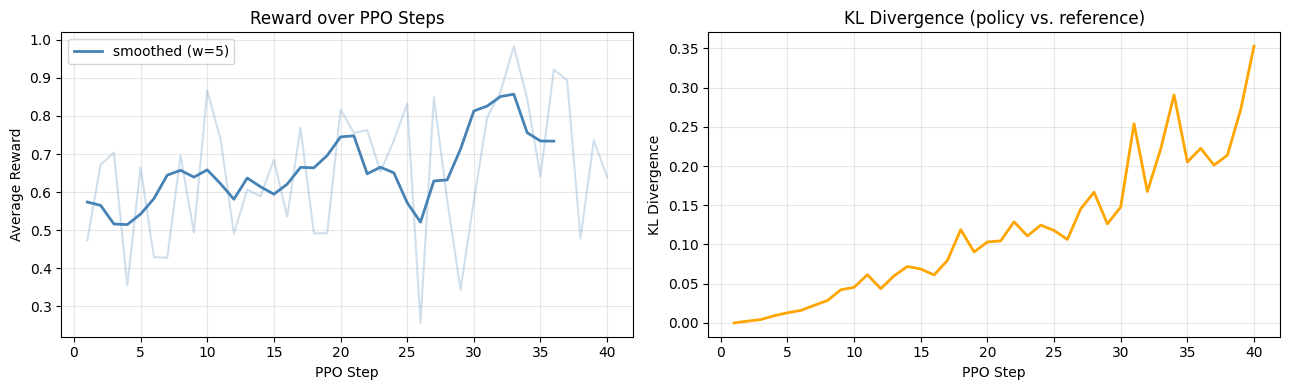

In [15]:
def smooth(data, w=5):
    if len(data) < w:
        return np.array(data)
    return np.convolve(data, np.ones(w) / w, mode='valid')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

steps = np.arange(1, len(ppo_reward_log) + 1)
ax1.plot(steps, ppo_reward_log, alpha=0.25, color='steelblue')
sm = smooth(ppo_reward_log)
ax1.plot(np.arange(1, len(sm) + 1), sm, color='steelblue', linewidth=2, label='smoothed (w=5)')
ax1.set_xlabel('PPO Step')
ax1.set_ylabel('Average Reward')
ax1.set_title('Reward over PPO Steps')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(steps, ppo_kl_log, color='orange', linewidth=2)
# (this from-scratch loop uses a fixed KL penalty coefficient, not a KL target)
ax2.set_xlabel('PPO Step')
ax2.set_ylabel('KL Divergence')
ax2.set_title('KL Divergence (policy vs. reference)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ppo_training.png', dpi=100, bbox_inches='tight')
plt.show()

## Before vs. After PPO: did it work?

We take the **same review prompts**, generate a continuation with the **before-PPO (SFT)** model and the **after-PPO** model, and score both with the sentiment classifier. If PPO worked, the *after* continuations should be **more positive** while staying coherent English.

> 📊 **How to read this honestly.** Some SFT continuations are already upbeat, so a few prompts won't move much. The trustworthy evidence is **(a)** the mean positivity rising and **(b)** the in-training `positivity` curve climbing over the run (printed above). A neutral/negative prompt flipping to clearly positive, e.g. *"Just saw this movie on TV…"* going from ~0.1 to ~0.99, is the steering effect made visible.


In [16]:
def generate_ppo_text(model, tokenizer, prompt, max_new_tokens=40):
    enc = tokenizer(prompt, return_tensors='pt', truncation=True, max_length=64)
    enc = {k: v.to(DEVICE) for k, v in enc.items()}
    model.eval()
    with torch.no_grad():
        out = model.generate(**enc, max_new_tokens=max_new_tokens, do_sample=True, temperature=0.7,
                             repetition_penalty=1.2, no_repeat_ngram_size=3,
                             pad_token_id=tokenizer.eos_token_id, suppress_tokens=NONLATIN_IDS)
    return tokenizer.decode(out[0][enc['input_ids'].shape[1]:], skip_special_tokens=True).strip()

print('=== Before vs. After PPO (positivity reward) ===')
print('=' * 62)
rb_list, ra_list = [], []
for i, prompt in enumerate(TEST_PROMPTS):
    resp_before = sft_responses_before[i]
    resp_after  = generate_ppo_text(ppo_model, ppo_tokenizer, prompt)
    rb = positivity(resp_before)
    ra = positivity(resp_after)
    rb_list.append(rb); ra_list.append(ra)
    print(f'\nPrompt: {prompt}')
    print(f'  Before (pos={rb:.2f}): {resp_before[:90]}')
    print(f'  After  (pos={ra:.2f}): {resp_after[:90]}')
print(f'\nMean positivity  before={np.mean(rb_list):.3f}  ->  after={np.mean(ra_list):.3f}')


=== Before vs. After PPO (positivity reward) ===

Prompt: I found this to be an
  Before (pos=0.98): amazing movie. But it is also very complex and has a lot of potential for the talented act
  After  (pos=1.00): excellent film. It is a very serious and moving story about the life of a woman during her

Prompt: I love killer Insects movies they
  Before (pos=0.99): are so entertaining and interesting to watch. The only problem is that the film is expensi
  After  (pos=1.00): are one of the most beautiful and thought provoking films ever made. The movie is a true s

Prompt: Alexandre Aja's remake of The Hills
  Before (pos=0.99): Have Passed is a faithful, modernized version. It continues the story and narrates it diff
  After  (pos=0.99): Have Fallen is a great thriller about the fall and rise of the Jussieu family in seventies

Prompt: Just saw this movie on TV
  Before (pos=0.14): last night. The actor who played the hero is a real man, but his character was not so; or 
  After  (pos

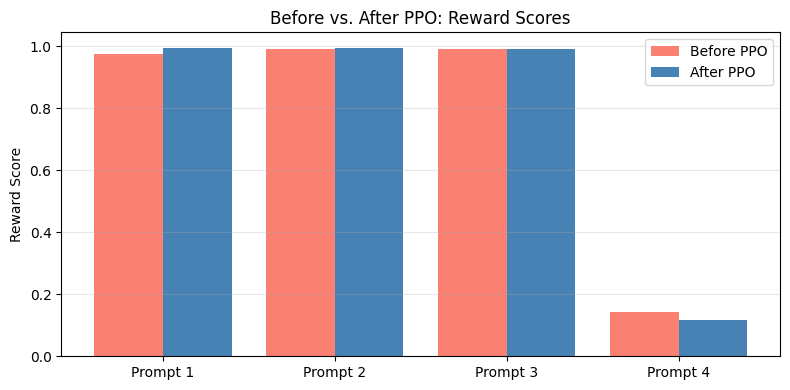

In [17]:
x = np.arange(len(TEST_PROMPTS))
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - 0.2, rb_list, 0.4, label='Before PPO', color='salmon')
ax.bar(x + 0.2, ra_list, 0.4, label='After PPO',  color='steelblue')
ax.set_xticks(x)
ax.set_xticklabels([f'Prompt {i+1}' for i in range(len(TEST_PROMPTS))])
ax.set_ylabel('Reward Score')
ax.set_title('Before vs. After PPO: Reward Scores')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('ppo_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

## Summary: the three-step dance, and what made it work

| Step | What we trained | Objective | Scale here |
|---|---|---|---|
| 1 · SFT | policy (Qwen2.5-0.5B, ~500 M params) | cross-entropy on review text | ~300 IMDB reviews, 1 epoch |
| 2 · RM  | reward model (backbone + scalar head) | Bradley-Terry on preference pairs | ~800 IMDB pos/neg pairs |
| 3 · PPO | policy + value head | clipped surrogate; reward = bounded sentiment classifier; KL leash | 40 steps × 8 rollouts |

### Key design choices (each fixes a real failure mode)
- **Bounded, pretrained reward** (`lvwerra/distilbert-imdb`, scores in [0, 1]), gibberish maps to ~neutral, so PPO **can't reward-hack**.
- **KL folded into the reward** (not added as a loss term), a loss-side KL term uniformly suppresses log-probs and **collapses** the policy.
- **Value head (critic)** estimates the baseline so the **advantage** `A = R − V` is a stable signal; it reads *detached* features so it can never corrupt the language model.
- **KL leash** (β = 0.1) keeps the policy near the fluent SFT model, preserving language quality.
- **Clipping** (ε = 0.2) stops any single update from moving the policy too far.

### What we observed
Average positivity climbed from **~0.54 to a peak of ~0.80 (0.76 at the final step)** during PPO, and the continuations remained **coherent English**, a genuine steering effect, not reward hacking. This was not a free ride, though: the KL divergence grew over the run (mean ~0.14, rising to ~0.35 by the end), so the leash loosened as training went on. Reward peaked near step 30 and then dipped before partly recovering, the classic sign of over-optimization, so stopping earlier would have given a cleaner result.

### Honest limitations of this toy
Production RLHF uses **millions** of preference labels, **thousands** of PPO steps, and **7B–70B**-parameter models. Our 0.5 B model, ~800 pairs, and 40 steps are a pedagogical stand-in, enough to see the mechanism clearly, not to build a production assistant.

> **Next chapter →** Chapter 7 introduces **DPO**, which removes the separate reward model *and* the RL loop by turning preference data directly into a supervised objective on the policy.


In [18]:
print('=== RLHF Training Summary ===')
print(f'SFT review texts         : {len(sft_texts)}')
print(f'Preference pairs (RM)    : {len(PREFERENCE_PAIRS)}')
print(f'PPO steps completed      : {PPO_STEPS}')
print(f'RM final accuracy        : {rm_accuracies[-1]:.2%}')
print(f'PPO reward, step 1      : {ppo_reward_log[0]:+.4f}')
print(f'PPO reward, last step   : {ppo_reward_log[-1]:+.4f}')
delta = ppo_reward_log[-1] - ppo_reward_log[0]
print(f'Reward improvement       : {"+" if delta >= 0 else ""}{delta:.4f}')
print(f'Mean KL divergence       : {np.mean(ppo_kl_log):.4f}')

=== RLHF Training Summary ===
SFT review texts         : 300
Preference pairs (RM)    : 800
PPO steps completed      : 40
RM final accuracy        : 99.62%
PPO reward, step 1      : +0.4728
PPO reward, last step   : +0.6397
Reward improvement       : +0.1669
Mean KL divergence       : 0.1156


## Production-Scale PPO: from toy to InstructGPT

**Quick orientation:** the policy we trained here is **Qwen2.5-0.5B**. We are *not* using InstructGPT or Gemini, those aren't models you load; they are **previously published applications of the same three-step RLHF algorithm** (SFT → RM → PPO) by OpenAI (2022) and Google. The table compares our toy run to those production runs so you can see how the same recipe scales by orders of magnitude.

| Dimension | This notebook (toy) | InstructGPT (OpenAI, 2022) | Gemini RLHF (Google DeepMind) |
|---|---|---|---|
| Base model size | 0.5 B | 175 B (GPT-3) | ~1 T (est.) |
| Reward signal | pretrained DistilBERT sentiment classifier | separate 6 B reward model | separate large reward model |
| PPO batch (rollouts/step) | 8 | 512+ | thousands |
| KL penalty β | 0.1 (fixed) | adaptive | adaptive |
| Hardware | 1× T4 | thousands of A100s | TPU v4 pods |
| Preference data | IMDB sentiment labels | ~40 k curated comparisons | undisclosed |

The **algorithmic structure (SFT → RM → PPO) is identical**; only the *scale* and the *base model* differ. That's the whole point of RLHF as a *technique*: it works on whatever base model you point it at.


In [19]:
# Production PPO config -- reference only (not executed).
# At scale you would typically use a maintained RLHF library (e.g. TRL's current
# PPOTrainer) rather than the teaching loop above. Illustrative settings:
PRODUCTION_PPO_CONFIG = {
    "model_name": "Qwen/Qwen2.5-7B-Instruct",
    "learning_rate": 1e-5,
    "batch_size": 64,
    "mini_batch_size": 8,
    "gradient_accumulation_steps": 8,
    "ppo_epochs": 4,
    "init_kl_coef": 0.2,
    "target_kl": 6.0,
    "cliprange": 0.2,
    "cliprange_value": 0.2,
    "vf_coef": 0.1,
    "seed": 42,
}
for _k, _v in PRODUCTION_PPO_CONFIG.items():
    print(f"{_k:>28}: {_v}")


                  model_name: Qwen/Qwen2.5-7B-Instruct
               learning_rate: 1e-05
                  batch_size: 64
             mini_batch_size: 8
 gradient_accumulation_steps: 8
                  ppo_epochs: 4
                init_kl_coef: 0.2
                   target_kl: 6.0
                   cliprange: 0.2
             cliprange_value: 0.2
                     vf_coef: 0.1
                        seed: 42


## Chapter Summary and Forward Pointer

**What we covered in Chapter 6:**
- The three-step RLHF dance: SFT → reward modeling → PPO.
- Building a reward model with the **Bradley-Terry** preference loss.
- Implementing **PPO from scratch in plain PyTorch** (rollout → reward → advantage → clipped update), no RL library, every step visible.
- Why a **bounded reward** and a **KL leash** are what prevent reward hacking, demonstrated by a run that genuinely steers sentiment without collapsing.

**PPO's main cost** is complexity and sample inefficiency: several models in memory and many online rollouts per update. Chapter 7 introduces **Direct Preference Optimization (DPO)**, which eliminates the reward model and the RL loop by converting preference data directly into a supervised objective, competitive alignment at a fraction of PPO's compute.
